***Title: Classification Models Assignment***

***Name: Gedion Sang***

***ID: CS-DA03-26010***

***Date: 13/03/2026***

# Classification Models

## 1. Load the dataset

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [2]:
# Load the dataset and convert to DataFrame
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name='target')

## 2. Explore The Dataset

In [3]:
# returns a count of normal values
print('Class Distribution:')
print(y.value_counts())

Class Distribution:
target
1    71
0    59
2    48
Name: count, dtype: int64


In [4]:
#get the first 5 rows
print("First 5 rows:")
X.head()

First 5 rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [5]:
#get summary of descriptive statistics
X.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


## 3.	Prepare the Data

In [6]:
#check for missing values
X.isnull().sum()

,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


### Train the Model

In [7]:
from sklearn.preprocessing import StandardScaler
# Scaling the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [8]:
# DataFrame to store results
results = pd.DataFrame(columns=['Model', 'Accuracy'])

In [9]:
results.value_counts()

,,count
Model,Accuracy,


## 4.	Build the Models:

In [10]:
# 1. Support Vector Machine
svm = SVC(random_state=42)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

In [11]:
# 2. K-Nearest Neighbors
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

In [12]:
# 3. Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)

In [13]:
# 4. Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [14]:
# 5. Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [15]:
# 6. Logistic Regression
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

## 5.	Evaluate the Models:

In [16]:
# Accuracy scores for all models
models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN', 'Naive Bayes', 'SVM']
predictions = [lr_pred, dt_pred, rf_pred, knn_pred, nb_pred, svm_pred]

for model, pred in zip(models, predictions):
    acc = accuracy_score(y_test, pred)
    print(f"{model}: {acc:.4f}")

Logistic Regression: 1.0000
Decision Tree: 0.9444
Random Forest: 1.0000
KNN: 0.9444
Naive Bayes: 1.0000
SVM: 1.0000


### Confusion Matrices

In [17]:
# Helper function for confusion matrix plotting
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=wine.target_names, yticklabels=wine.target_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix: {title}')
    plt.show()


Logistic Regression
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



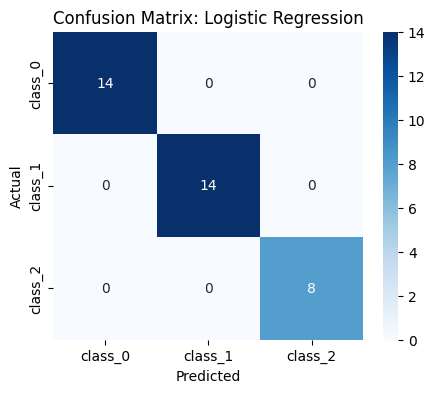

In [18]:
#Logistic Regression Classification Report and Confusion Matrix
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression\n", classification_report(y_test, y_pred_lr))
results.loc[len(results)] = ['Logistic Regression', accuracy_score(y_test, y_pred_lr)]
plot_conf_matrix(y_test, y_pred_lr, "Logistic Regression")

SVM
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



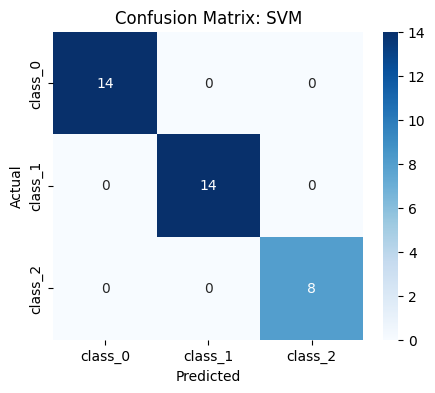

In [19]:
#SVM Classification Report and Confusion Matrix
svm = SVC(random_state=42)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
print("SVM\n", classification_report(y_test, svm_pred))
results.loc[len(results)] = ['SVM', accuracy_score(y_test, svm_pred)]
plot_conf_matrix(y_test, svm_pred, "SVM")


KNN
               precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       1.00      0.86      0.92        14
           2       0.89      1.00      0.94         8

    accuracy                           0.94        36
   macro avg       0.94      0.95      0.94        36
weighted avg       0.95      0.94      0.94        36



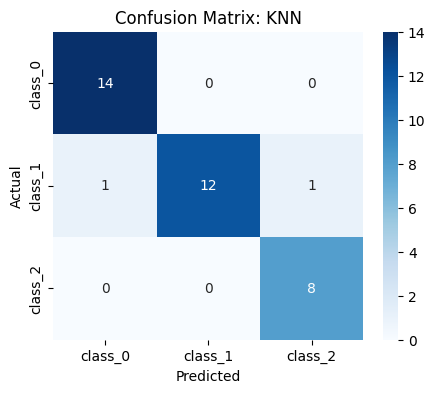

In [20]:
#KNN Classification Report and Confusion Matrix
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
print("KNN" + "\n", classification_report(y_test, knn_pred))
results.loc[len(results)] = ['KNN', accuracy_score(y_test, knn_pred)]
plot_conf_matrix(y_test, knn_pred, "KNN")

Naive Bayes
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



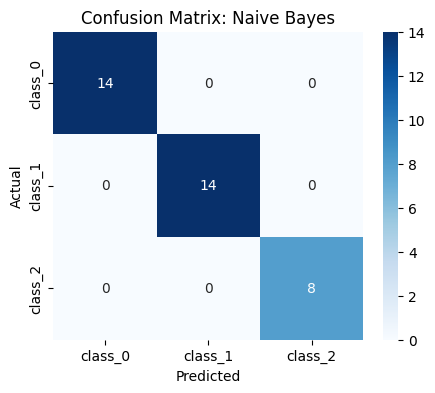

In [21]:
#Naive Bayes Classification Report and Confusion Matrix
nb = GaussianNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)
print("Naive Bayes" + "\n", classification_report(y_test, nb_pred))
results.loc[len(results)] = ['Naive Bayes', accuracy_score(y_test, nb_pred)]
plot_conf_matrix(y_test, nb_pred, "Naive Bayes")

Random Forest
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



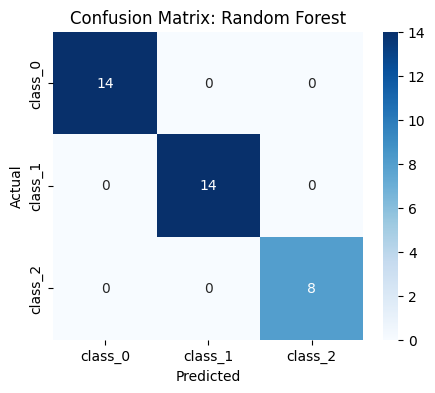

In [22]:
#Random Forest Classification Report and Confusion Matrix
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest" + "\n", classification_report(y_test, rf_pred))
results.loc[len(results)] = ['Random Forest', accuracy_score(y_test, rf_pred)]
plot_conf_matrix(y_test, rf_pred, "Random Forest")

Decision Tree
               precision    recall  f1-score   support

           0       0.93      0.93      0.93        14
           1       0.93      1.00      0.97        14
           2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.95      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36



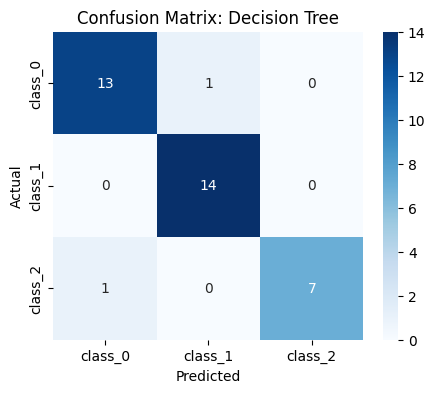

In [23]:
#Decision Tree Classification Report and Confusion Matrix
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
print("Decision Tree" + "\n", classification_report(y_test, dt_pred))
results.loc[len(results)] = ['Decision Tree', accuracy_score(y_test, dt_pred)]
plot_conf_matrix(y_test, dt_pred, "Decision Tree")

## 6.	Compare the models:

/tmp/ipykernel_27820/1658097278.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results, palette='viridis')


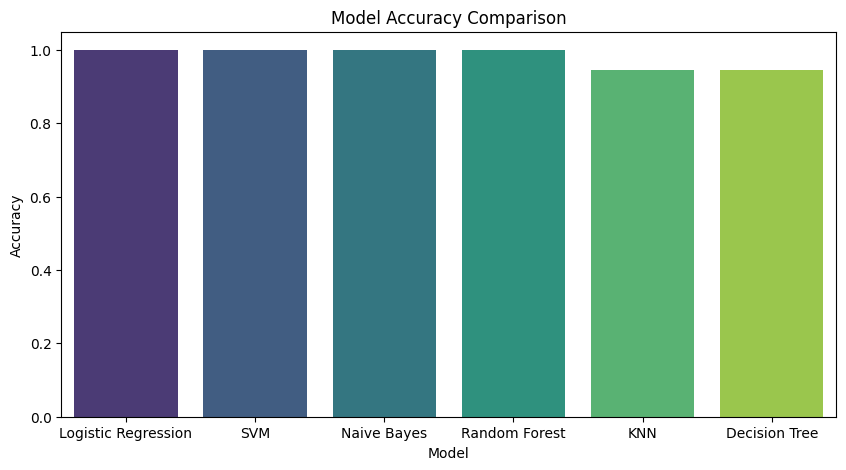

In [24]:
#sort the results in descending order
results = results.sort_values('Accuracy', ascending=False)
# Bar chart comparison
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='Accuracy', data=results, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.show()
